# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Capstone Project | 💧Water Potability Prediction</p>

Capstone Project |
💧Water Potability Prediction

Problem

Objective :
The goal of this project is to develop a machine learning model to predict water potability based on various water quality parameters. This model will help in assessing whether water is safe for consumption, which is crucial for public health and water management

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color:white; font-size:115%; text-align:left">

<h3 align="left"><font color=skyblue>Table of Contents:</font></h3>
    
* [Step 1 | Import Libraries](#import)
* [Step 2 | Read Dataset](#read)
* [Step 3 | Dataset Overview](#overview)
    - [Step 3.1 | Dataset Basic Information](#basic)
    - [Step 3.2 | Summary Statistics for Numerical Variables](#num_statistics)
* [Step 4 | EDA](#eda)
    - [Step 4.1 | EXploratory Data Analysis(EDA)](#eda)
    - [Step 4.2 | Missing Value Analysis](#missing_value)
    - [Step 4.3 | Feature Distribution Analysis](#fd_analysis)
    - [Step 4.4 | Box plot for Outlier Detection](#box_plts)    
    - [Step 4.5 | Correlation Analysis](#corr_analysis)
* [Step 5 | Data Preprocessing](#preprocessing)
    - [Step 5.1 | Missing Value Treatment](#missing_value_treatment)
    - [Step 5.2 | Outlier Treatment](#outlier)
    - [Step 5.3 | Handling Missing Values (Simple Imputer)](#imputer)
    - [Step 5.4 | Feature Scaling](#scaling)
    - [Step 5.5 | Train Test Split](#split)
    - [Step 5.6 | Handling Class Imbalance Using SMOTE](#smote)
* [Step 6 |  Model Selection & Training](#model_selection)
    - [Step 6.1 | SVC Model Training](#svc_training)
    - [Step 6.2 | Random Forest Model Training](#rf_training)
    - [Step 6.3 | KNN Model Training](#knn_training)
    - [Step 6.4 | Decision Tree Model Training](#dt_training)                                       
    - [Step 6.5 | XGBoost Model Training ](#xgb_training)                                       
    - [Step 6.6 | Model Evaluation](#model_eval)                                       
    - [Step 6.7 | Cross-Validation](#cross_val)
* [Step 7 | Hyperparameter Tuning](#Hyper_tuning)
    - [Step 7.1 |RF Hyperparameter Tuning](#rf_tuning)
    - [Step 7.2 | XGBoost Hyperparameter Tuning ](#xgb_tuning)
* [Step 8 |Model Evaluation](#model_eval)
    - [Step 8.1 | Model Evaluation using accuracy, precision, recall, F1-score and Confusion Matrices ](#models_eval)
    - [Step 8.2 | ROC Curve & AUC Score](#roc_auc)
* [Step 9 | Feature Importance](#rf)

<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

In [6]:
pip install imbalanced-learn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

In [1]:
import  pandas as pd 
import numpy as np 

#matplotlib inline
import matplotlib.pyplot as plt  
import seaborn as sns 
from matplotlib.colors import ListedColormap 

from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 
from sklearn.impute import SimpleImputer 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier 
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


from imblearn.over_sampling import SMOTE

import joblib




In [3]:
# Set the resolution of the plotted figures
plt.rcParams['figure.dpi'] = 200

# Configure Seaborn plot styles: Set background color as dark| grid
sns.set(style='darkgrid')

<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

Load the Dataset

In [4]:
df = pd.read_csv("water_potability.csv")

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left"> 
Renaming feature column (sulfate -> Sulphate),
we rename sulfate -> Sulphate in this project for better readability and consistency through out the presentation. Where it does not affect the data or model performance 

In [5]:
#Renaming a column 
df.rename(columns={"Sulfate": "Sulphate"}, inplace=True)
print(df.columns)

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulphate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')


In [6]:
df

,ph,Hardness,Solids,Chloramines,Sulphate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [7]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulphate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulphate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:120%; text-align:left">

<h2 align="left"><font color=black>Dataset Description:</font></h2>
    
| __Variable__ | __Description__ |
|     :---      |       :---      |      
| __ph__ | Determines whether the water is acidic or alkaline, ph range recommended for potability is usually 6.5 - 8.5. |
| __Hardness__ | Concentration of calcium and magnesium minerals in water |
| __Solids__ |Total Dissolved Solids (TDS) refers combined amount of inorganic salts and organic matter present measured in mg/L or ppm. |
| __Chloramines__ | Chloramines are the disinfectant used for killing harmful bacteria and viruses, which is a combination of chlorine and ammonia.|
| __Sulfates__ | sulfates are measured to prevent health issues in infants like diarrhea,corrosion and unpleasant taste.Safe limit set between 250 - 500 mg/L. |                     
| __Conductivity__ |Refers to the measure the concentration of dissolved ions(like calcium,magnesium,sodium,chloride) which indicates water purity, preferred potability ranges from (30-800 µS/cm). |
| __Organic_Carbon__ |Measuring organic carbon in drinking water indicates the presence of organic matter that reacts with disinfectant like chlorine to form harmful disinfection byproducts(DBPs), such as trihalomethanes(THMs), which are liked to cancer and other heath issues. |  
| __Trihalomethanes__ |Trihalomethanes(THMs) are disinfection byproducts formed when chlorine reacts with organic matter in water, long term exposure leads to bladder cancer and potential reproductive issues.|                      
| __Turbidity__ | It is measure of cloudiness present in water due the amount of suspended particles, safe drinking water normally measures below 1 NTU(Nephelometric Turbidity Unit). |
| __Potability__ |Water safety status (0=Not Potable, 1= Potable) |

<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 |  Dataset Overview</p>

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

In this step we will explore deeper into the dataset:

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 3.1 |</span><span style='color:white'> Dataset Basic Information</span></b>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulphate         2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [10]:
# Defines the number of entries and columns
df.shape

(3276, 10)

In [11]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulphate           781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

<h2 align="left"><font color=black>Inferences:</font></h2>

* __Number of Entries__: The dataset consists of __3276 entries__, ranging from index 0 to 3275.
    
    
* __Columns__: There are __10 columns__ in the dataset corresponding to various parameters of the water and their results.
    
    
* __Data Types__:
    - Most of the columns (9 out of 10) are of the __float64__ data type.
    - Only the Potability column is of the int64 data type.
    
    
* __Missing Values__: There appears to be missing values in the following
(1) ph:491               missing values (3276-2785)
(2) Sulfate:781          missing values (3276-2495)
(3) Trihalomethanes:162  missing values (3276-3114)

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 3.2 |</span><span style='color:white'> Summary Statistics Numerical Variables</span></b>

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulphate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

<h2 align="left"><font color=black>Inferences:</font></h2>


### Summary Statistics of Numerical Water Quality Parameters

The table above provides descriptive statistics for all numerical features in the water potability dataset.  
These statistics help us understand the overall distribution, central tendency, and variability of each water quality parameter before performing preprocessing and model training.

For each feature, the following values are reported:

- **Count**: Number of available (non-missing) observations  
- **Mean**: Average value of the parameter  
- **Standard Deviation (std)**: Measure of spread or variability in the data  
- **Minimum and Maximum**: Range of values observed  
- **Quartiles (25%, 50%, 75%)**: Indicate how the values are distributed across the dataset 

Summary of the given table
- The **pH** values range from acidic (0) to alkaline (14), with an average around 7, indicating mostly neutral water samples.
- **Hardness**, **Solids**, and **Conductivity** show high variation, suggesting differences in mineral and salt content across samples.
- **Sulphate** and **Trihalomethanes** have fewer observations compared to other features, indicating the presence of missing values that must be handled during preprocessing.
- The target variable **Potability** has a mean of 0.39, meaning only about 39% of water samples are potable, showing class imbalance in the dataset.

Overall, these statistics provide important insights for detecting missing values, outliers, and the need for scaling before building machine learning models.


<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | Exploratory Data Analysis(EDA) </p>

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 4.1 |</span><span style='color:white'> Target Variable Distribution (Potability) </span></b>

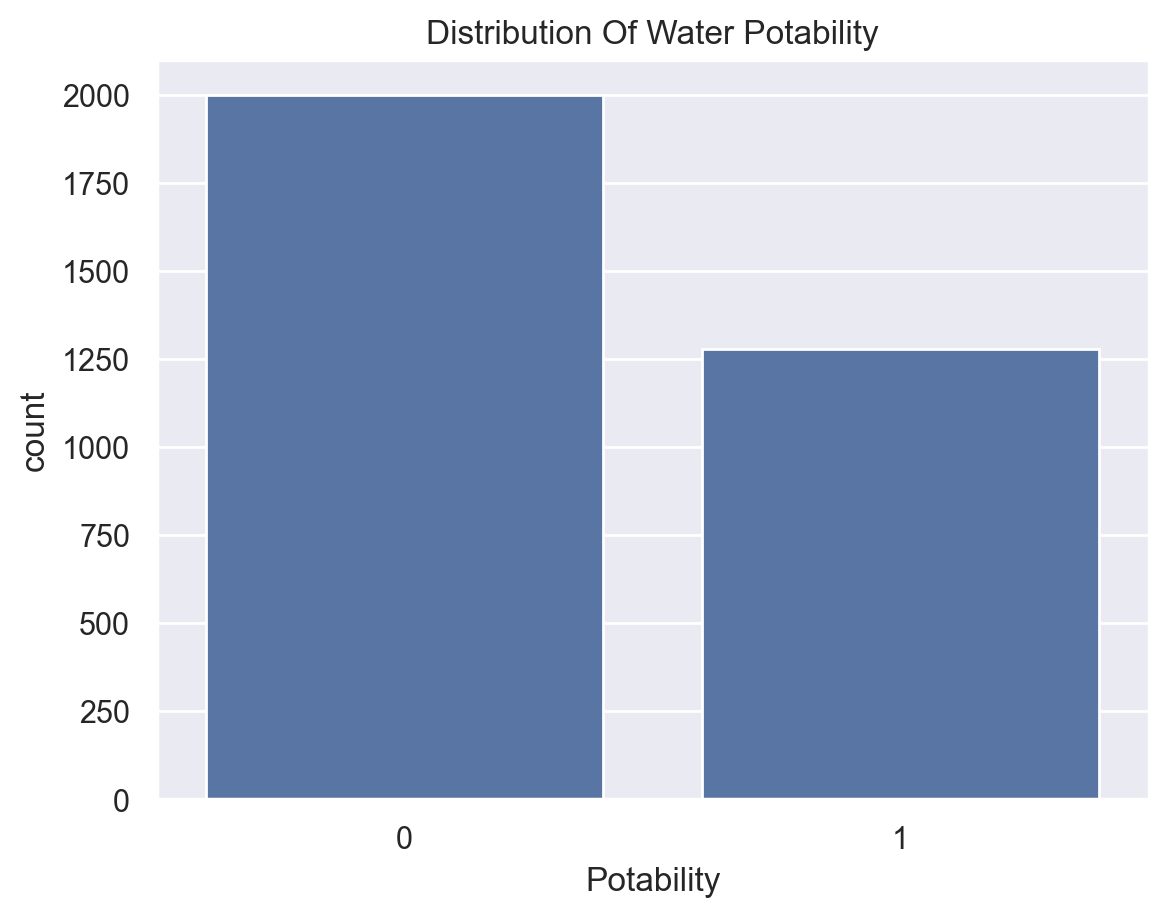

In [13]:
sns.countplot(x='Potability', data=df)
plt.title('Distribution Of Water Potability')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

<h2 align="left"><font color=black>Inferences:</font></h2>

### Target Variable Distribution (Potability)
The bar chart shows us the distribution of target variable which is **Potability**

* **0** Represents the **non-potable** water which is unsafe to drink.
* **1** Represents the **Potable** water which is safe to drink.

From the chart it is clear that number of non-potable water sample is higher than potable water.
* which indicates that a **class imbalance** is in the dataset,and is the reason why we use technique like **SMOTE** as we proceed to balance the classes before training the machine learning model. 

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 4.2 |</span><span style='color:white'> Missing Value Analysis </span></b>

In [14]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulphate           781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

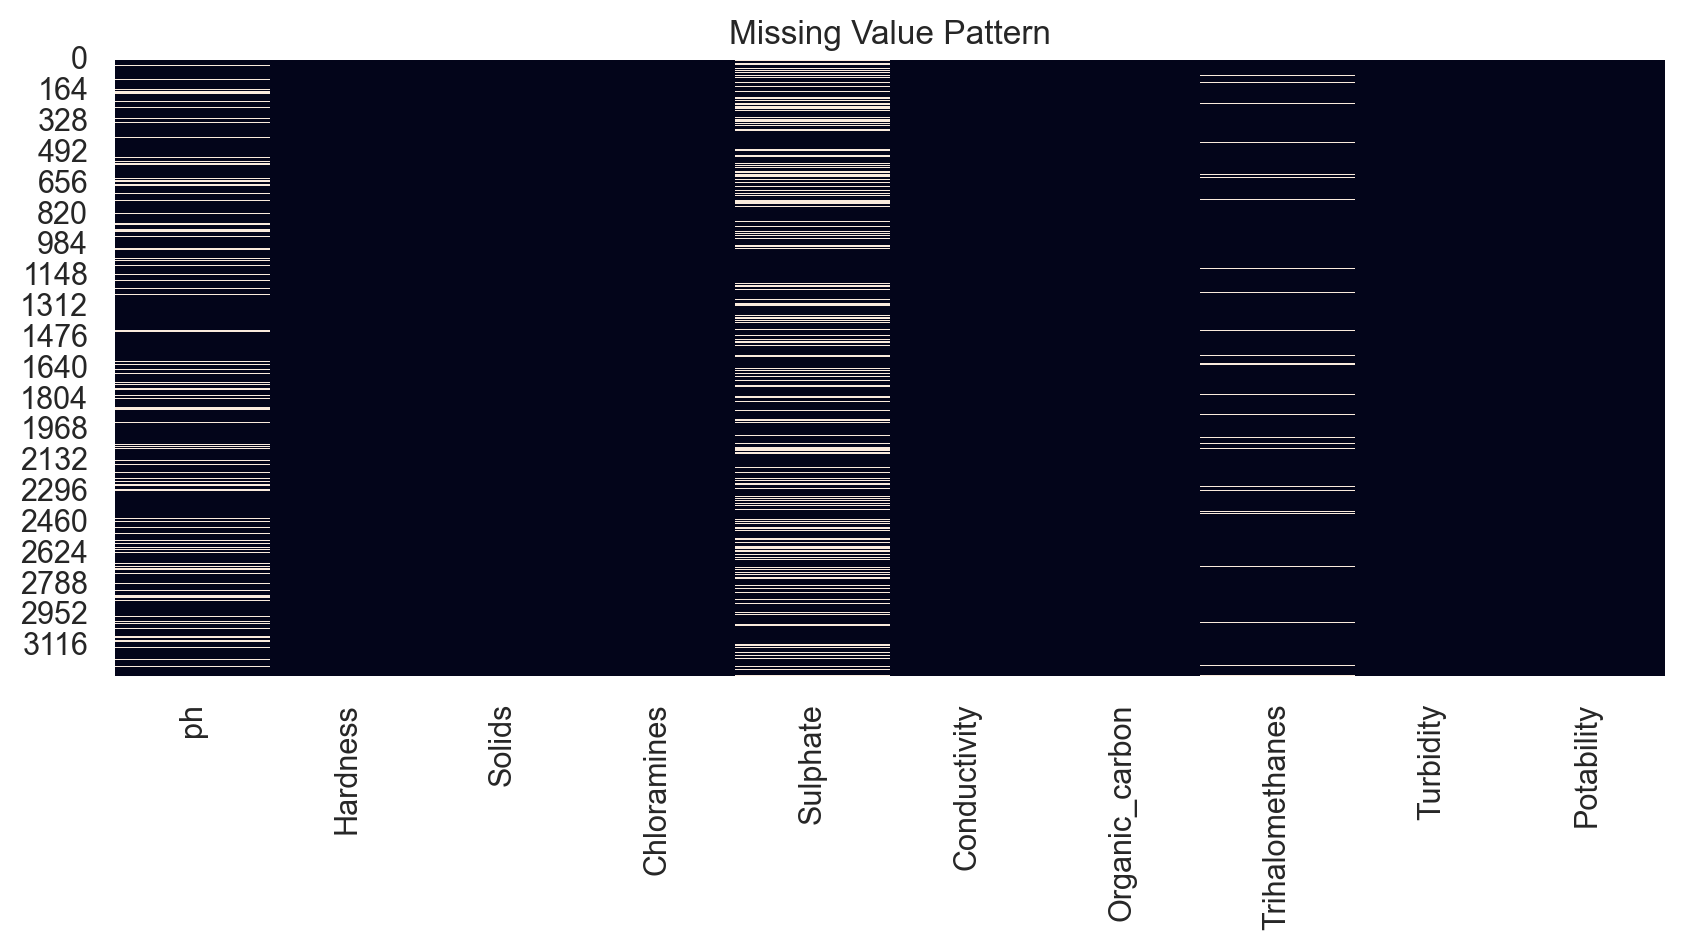

In [15]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Value Pattern')
plt.show

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left"> 
The heatmap above shows the pattern of missing values in the dataset.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 4.3 |</span><span style='color:white'> Feature Distribution Analysis </span></b>

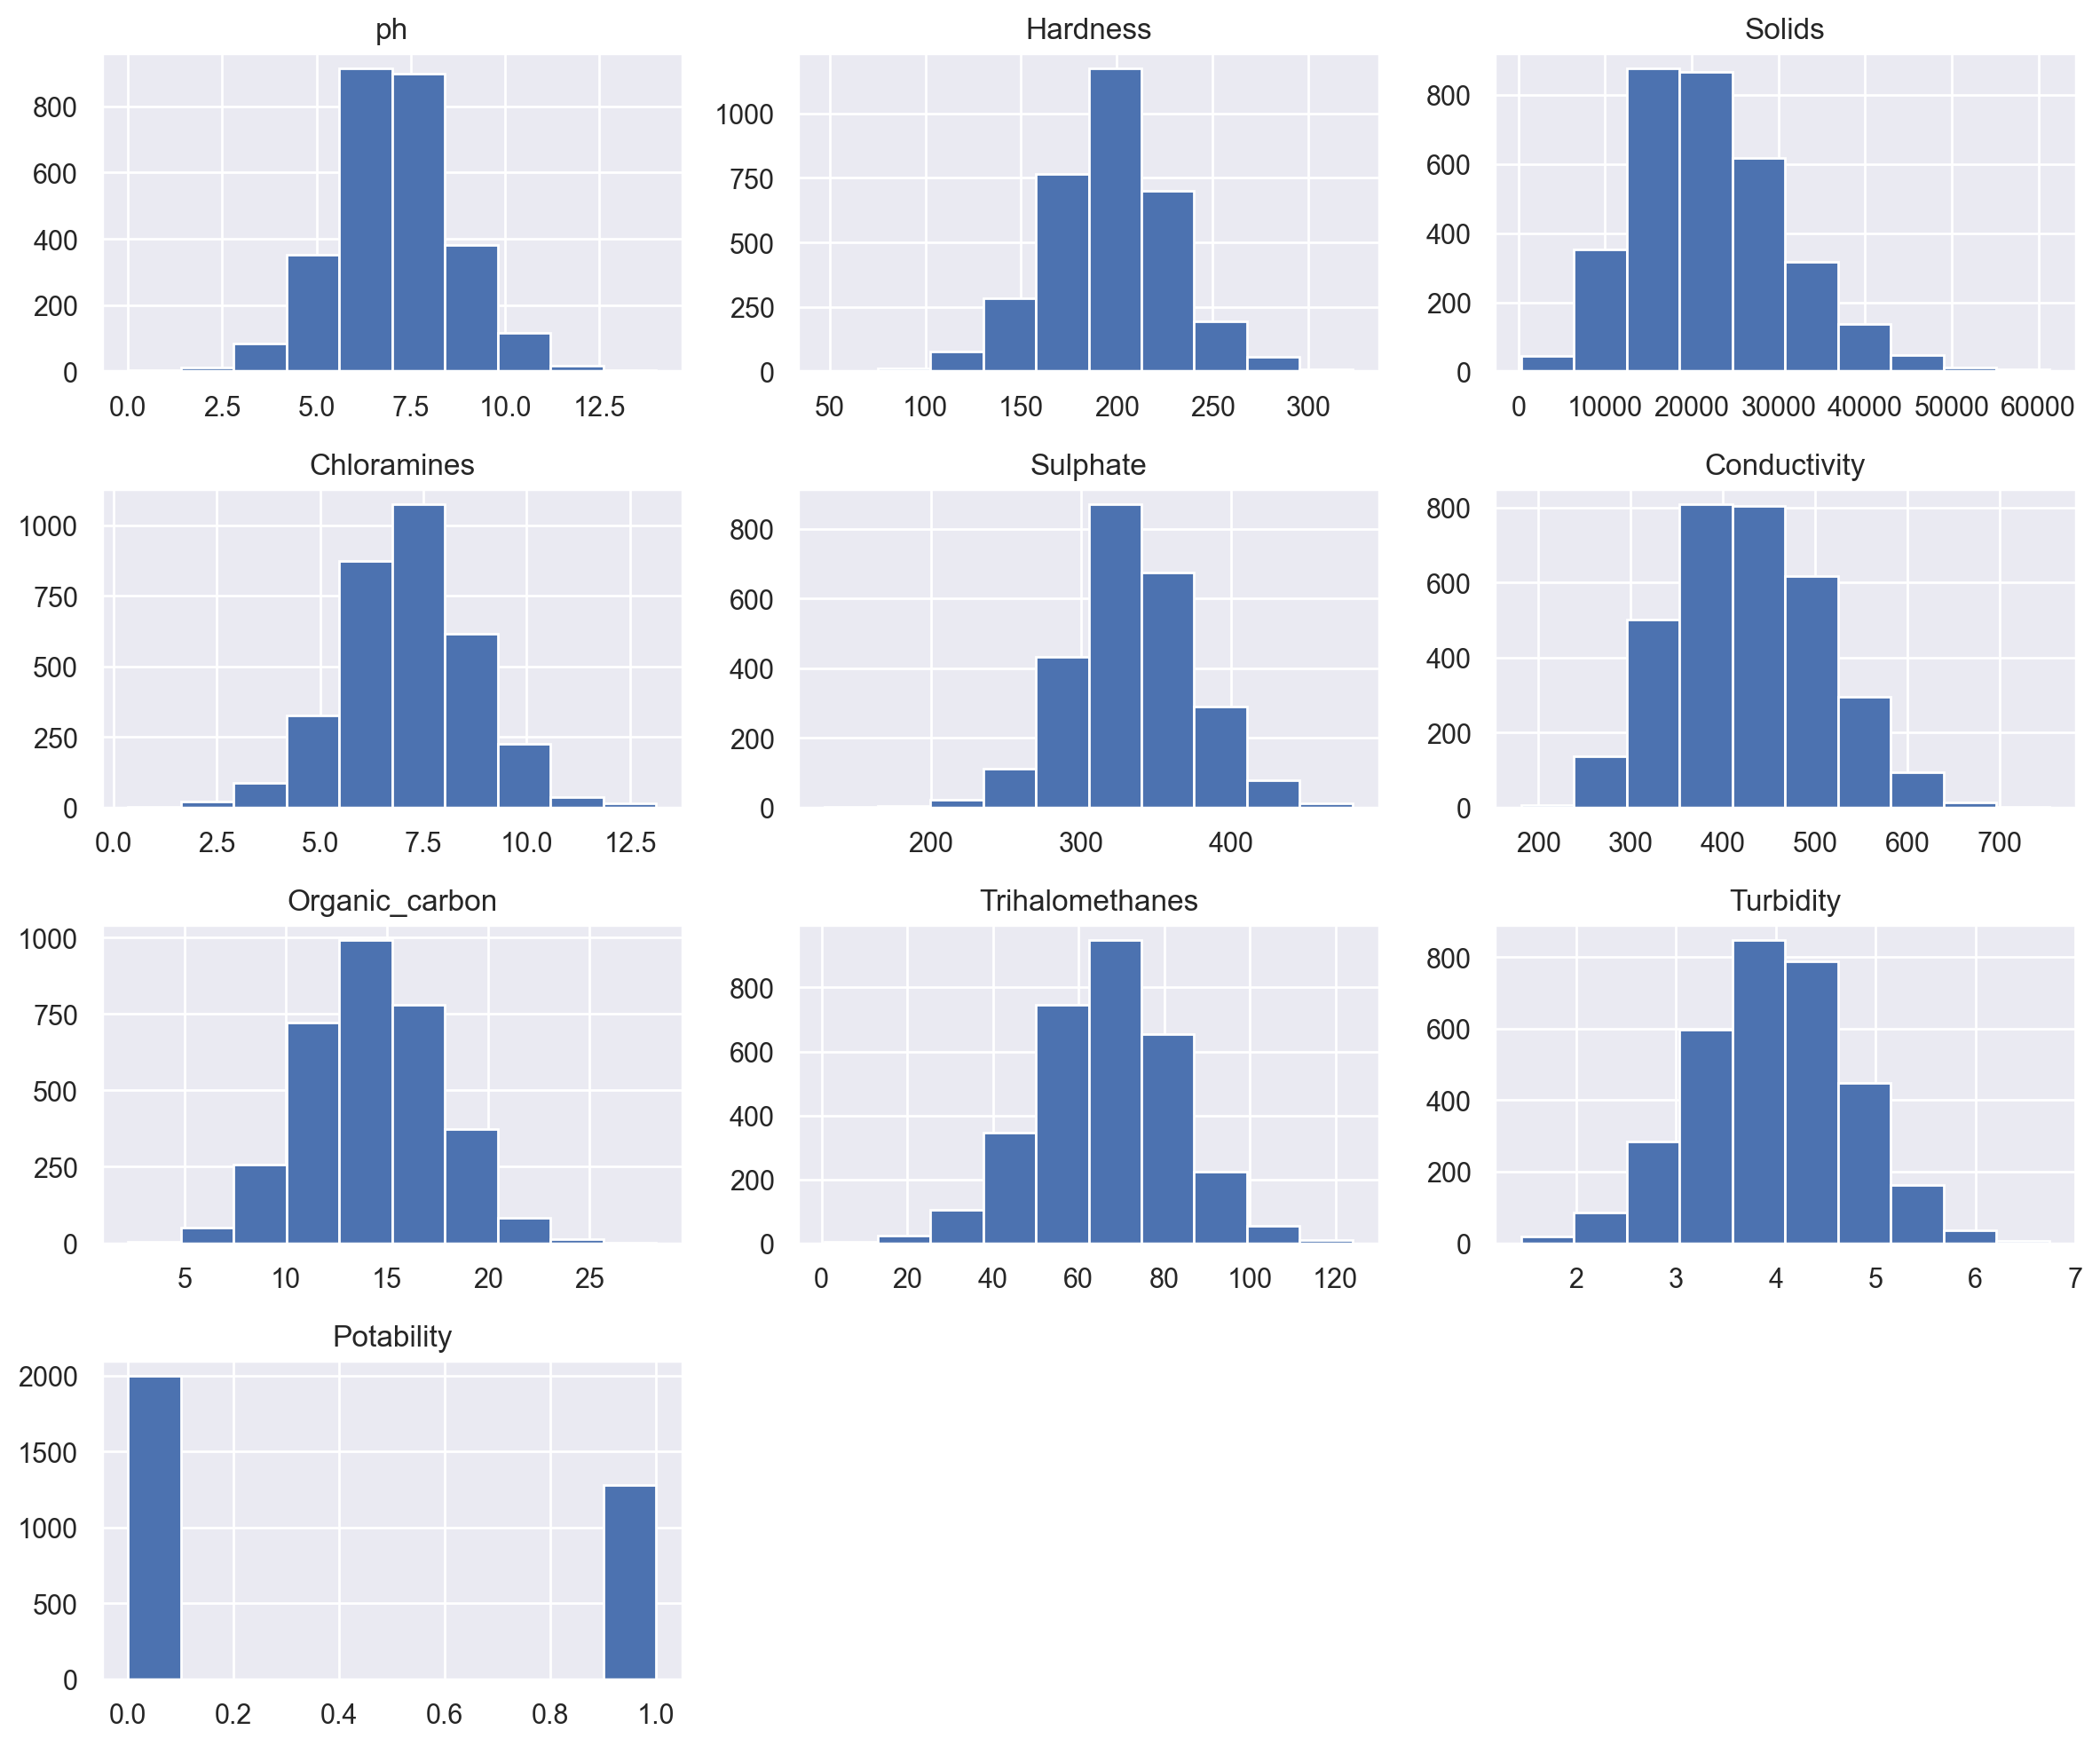

In [16]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left"> 

### Feature Distribution Analysis:

The histograms above show the distribution of each numerical water quality feature in the dataset.

By visualizing these distributions, we can understand:

- Most features such as **pH**, **Hardness**, **Chloramines**, and **Turbidity** follow approximately normal pattern.
- Some variables like **Solids** and **Conductivity** have wider ranges, indicating higher variability across water samples.
- The target variable **Potability** is binary, with more samples belonging to class **0 (non-potable)** than class **1 (potable)**.

Understanding feature distributions is important for detecting skewness, outliers, and determining whether scaling or transformation is needed before training machine learning models.



<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 4.4 |</span><span style='color:white'>Box plots for Outlier Detection </span></b>

C:\Users\VAISHAKH T\AppData\Local\Temp\ipykernel_30268\101871242.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna()for col in features],


Text(0, 0.5, 'Feature Values')

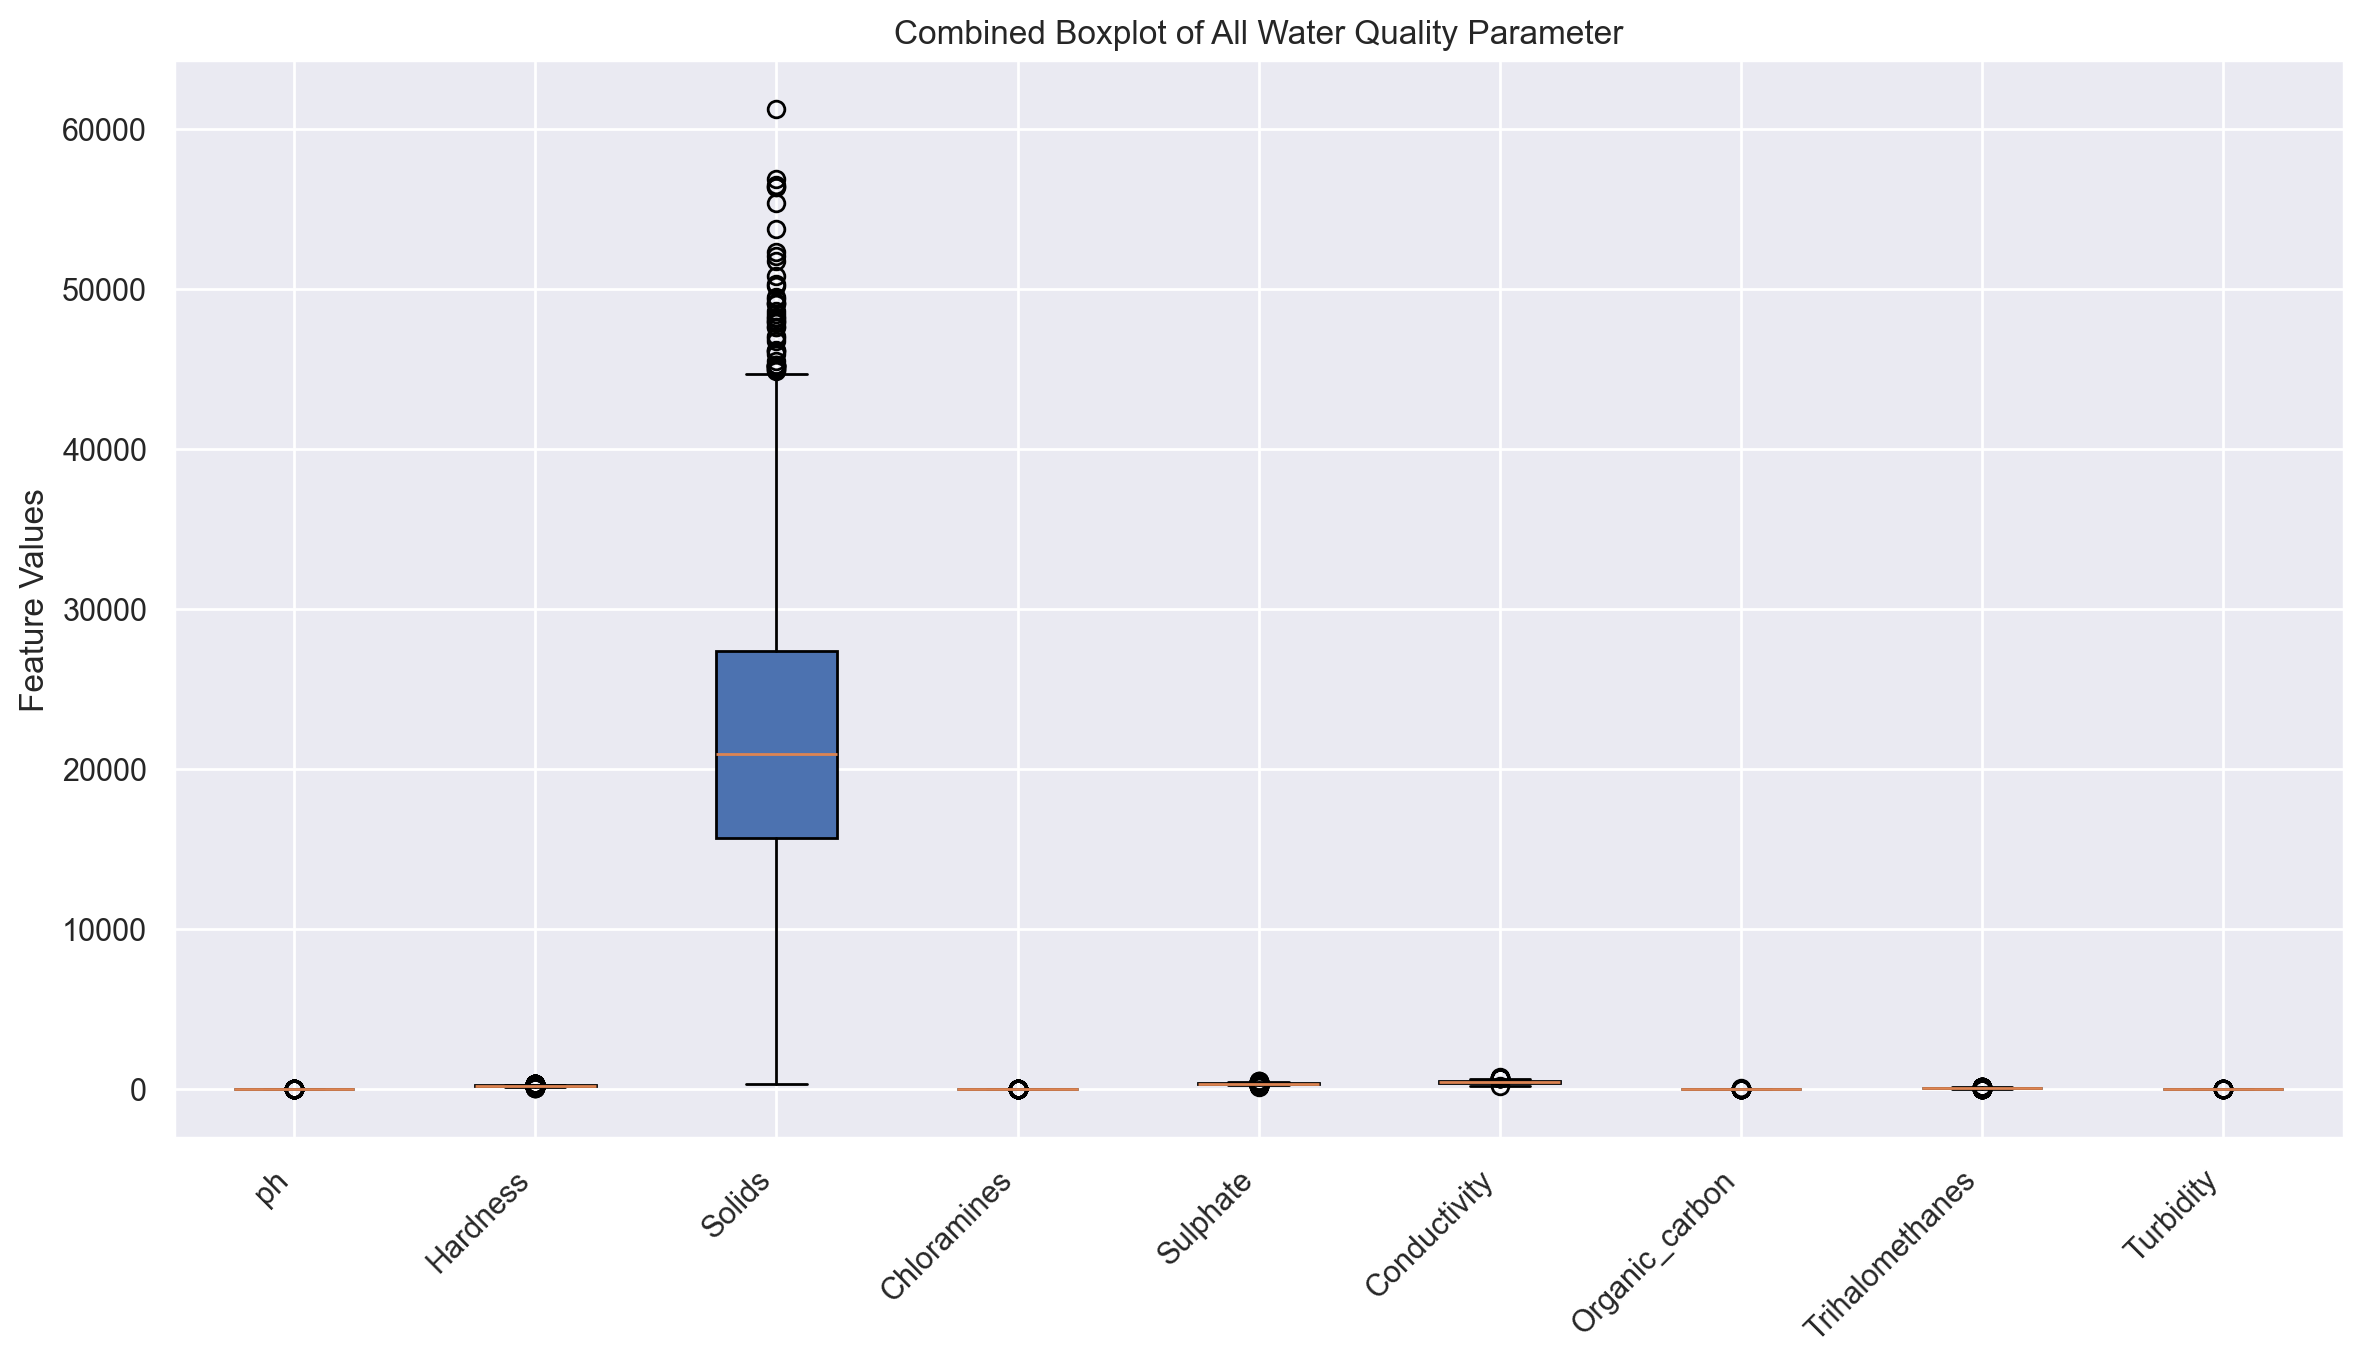

In [17]:
features = df.columns[:-1]

plt.figure(figsize=(14,7))

plt.boxplot([df[col].dropna()for col in features],
            labels=features,
            patch_artist=True)
plt.xticks(rotation=45, ha="right")
plt.title("Combined Boxplot of All Water Quality Parameter")
plt.ylabel("Feature Values")

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left"> 
 
 ### Inference:

Boxplots are an important exploratory data analysis (EDA) tool used to understand the distribution of numerical features and to identify the presence of outliers in the dataset.

### **What does a Boxplot determine?**

A boxplot summarizes the spread of a feature using five key statistics:

- **Minimum value**
- **First Quartile (Q1)** – 25% of the data lies below this point
- **Median (Q2)** – the middle value of the feature
- **Third Quartile (Q3)** – 75% of the data lies below this point
- **Maximum value**

The whiskers represent the normal range of the data, while points plotted outside the whiskers indicate **potential outliers**.
- The orange line inside the box represents the median (Q2), which is the middle value of the feature. It divides the data such that 50% of observations lie above it and 50% lie below it.


---

### **Purpose of Using Boxplots in This Project**

In the Water Potability Prediction dataset, features such as *Turbidity*, *Conductivity*, *Organic Carbon*, and *Trihalomethanes* may contain extreme values due to natural variations in water quality measurements.

The main purposes of using boxplots here are:

- To visually inspect the distribution of each water quality parameter  
- To detect extreme values (outliers) that may affect model training  
- To understand the variability and range of different chemical properties  
- To decide whether preprocessing steps like scaling or transformation are required  

---

### **Why Outlier Detection is Important**

Outliers can impact machine learning algorithms differently:

- Distance-based models such as **KNN** and **SVM** are sensitive to outliers  
- Tree-based models like **Random Forest** and **Decision Trees** are more robust  

Therefore, identifying outliers helps ensure better preprocessing and improves model performance.

---

### **Conclusion**

Boxplots provide a clear visualization of potential outliers in water quality features. Instead of removing these values directly, feature scaling techniques are applied later to minimize their influence during model training.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 4.5 |</span><span style='color:white'> Correlation Analysis </span></b>

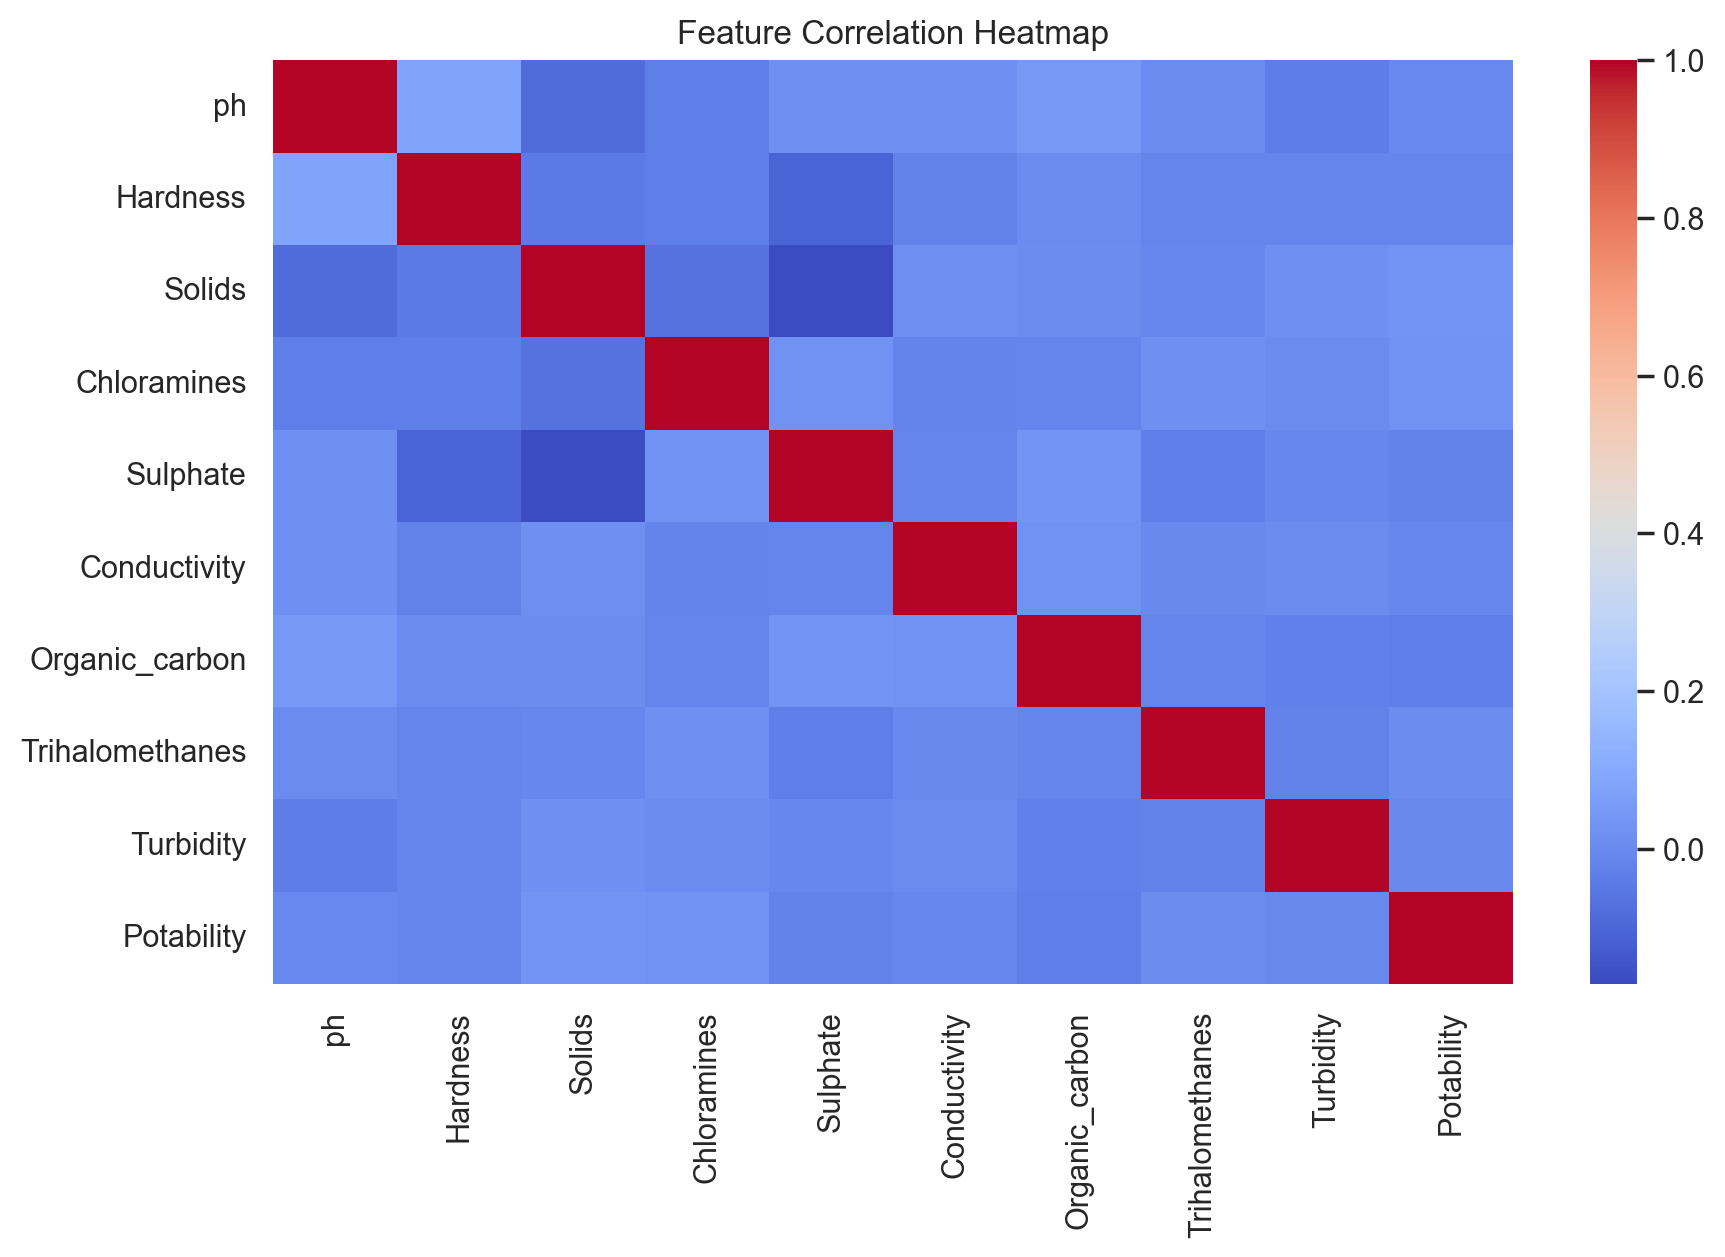

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

| Feature | Comparative Observation | Inference |
|-------|--------------------------|----------|
| pH | Potable samples closer to neutral | Extreme pH reduces potability |
| Hardness | Significant overlap | Weak standalone indicator |
| Solids | Higher variability in non-potable | Excess solids reduce quality |
| Chloramines | Safer range in potable samples | Proper disinfection essential |
| Sulfate | Higher extremes in non-potable | High sulfate linked to poor quality |
| Conductivity | Higher in non-potable | Indicates excess ions |
| Organic Carbon | Slightly higher in non-potable | Suggests organic contamination |
| Trihalomethanes | High variability in non-potable | Associated with health risks |
| Turbidity | Lower in potable samples | High turbidity reduces safety |


<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Data Preprocessing </p>

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 5.1 |</span><span style='color:white'> Missing Value Treatment </span></b>

In [19]:
#Checking for missing values in the dataset
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulphate           781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [20]:
df.isnull().sum().sum()

np.int64(1434)

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left"> 

### Missing Value Treatment:

From the above results it is clear how many missing values are seen in each water quality parameter.

-  **pH**,  seems to have 491 missing values.
-  **Sulphate**,  having 781 missing values.
- **Trihalomethannes**, having 162 missing values.
- All other features, including the target variable are having no missing values.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 5.2 |</span><span style='color:white'> Outlier Treatment </span></b>

In [21]:
#Define continuous features for all except potability
continuous_features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulphate', 'Conductivity', 'Organic_carbon','Trihalomethanes', 'Turbidity']

#calculating Quantiles and IQR
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1

#Identify and count outliers
outliers_count = pd.DataFrame({ 'Outlier_count': ((df[continuous_features] < (Q1 - 1.5 * IQR)) | (df[continuous_features] > (Q3 + 1.5 * IQR))).sum() })

print("Outlier Count per Features:\n")
print(outliers_count)

Outlier Count per Features:

                 Outlier_count
ph                          46
Hardness                    83
Solids                      47
Chloramines                 61
Sulphate                    41
Conductivity                11
Organic_carbon              25
Trihalomethanes             33
Turbidity                   19


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
Outliers were detected across multiple water quality parameters, indicating natural variability in real-world water samples. Here the outliers were not removed as most of the parameters are valid extreme water conditions.Thus their impact will be reduced through median imputation and feature scaling.  


In [22]:
df.isnull().sum().sum()

np.int64(1434)

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 5.3 |</span><span style='color:white'> Handling Missing Values (Simple Imputer) </span></b>

In [23]:
imputer = SimpleImputer(strategy='median')
df[continuous_features] = imputer.fit_transform(df[continuous_features])

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inferences:</font></h2>

Why median imputation is selected :
* The dataset contains outliers which is seen in EDA.
* Mean imputation is sensitive to extreme values than median.
* Median being robust to outliers is the reason it is used.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 5.4 |</span><span style='color:white'> Feature Scaling </span></b>

In [24]:
#Define the features (X) and the output  label (y)

X = df.drop('Potability', axis=1)
y = df['Potability']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 5.5 |</span><span style='color:white'> Train Test Split </span></b>

In [25]:
#Splitting the data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 5.6 |</span><span style='color:white'> Handling Class Imbalance Using SMOTE </span></b>

In [26]:
#Smote was applied only to the training data to avoid data leakage.
smote =  SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

pd.Series(y_train_resampled).value_counts()

Potability
0    1598
1    1598
Name: count, dtype: int64

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inferences:</font></h2>

The target variable Potability is imbalanced which means:
* one class appears significantly more than other.
* Models might get biased towards majority class.

<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Model Selection & Training </p>

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
Model training of all selected model done after dataset was resampled using SMOTE.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.1 |</span><span style='color:white'> Support Vector Classifier (SVC) </span></b>

In [27]:
svc = SVC(probability=True, random_state=42)
svc.fit(X_train_resampled, y_train_resampled)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
Here we carried out the SVC model training using the data that is applied with SMOTE, where as the test data remain untouched.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.2 |</span><span style='color:white'> Random Forest </span></b>

In [28]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.3 |</span><span style='color:white'> K-Nearest Neighbors </span></b>

In [29]:
knn = KNeighborsClassifier()
knn.fit(X_train_resampled, y_train_resampled)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.4 |</span><span style='color:white'> Decision Tree</span></b>

In [30]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_resampled, y_train_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.5 |</span><span style='color:white'> XGboost </span></b>

In [31]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_resampled, y_train_resampled)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.5 |</span><span style='color:white'> Model Evaluation</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inferences:</font></h2> 
The below step also done for model training

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
Random Forest

In [32]:
#The [:, -1] used to take all the row and the last columns as well
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,-1]


print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.70      0.75      0.72       400
           1       0.56      0.50      0.53       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.63       656
weighted avg       0.65      0.65      0.65       656



<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
Support Vector Classifier (SVC)

In [33]:
y_pred = svc.predict(X_test)
y_prob = svc.predict_proba(X_test)[:-1]

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.63      0.83      0.72       400
           1       0.46      0.22      0.30       256

    accuracy                           0.59       656
   macro avg       0.54      0.53      0.51       656
weighted avg       0.56      0.59      0.55       656



<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
K Nearest Neighbors (KNN)

In [34]:
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:,-1]

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.63      0.55      0.59       400
           1       0.42      0.50      0.45       256

    accuracy                           0.53       656
   macro avg       0.52      0.52      0.52       656
weighted avg       0.55      0.53      0.54       656



<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
Decision Tree

In [35]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.61      0.64       400
           1       0.46      0.52      0.49       256

    accuracy                           0.58       656
   macro avg       0.57      0.57      0.56       656
weighted avg       0.59      0.58      0.58       656



In [36]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.69      0.68       400
           1       0.49      0.47      0.48       256

    accuracy                           0.60       656
   macro avg       0.58      0.58      0.58       656
weighted avg       0.60      0.60      0.60       656



<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.6 |</span><span style='color:white'> Model comparison - Bar chart </span></b>

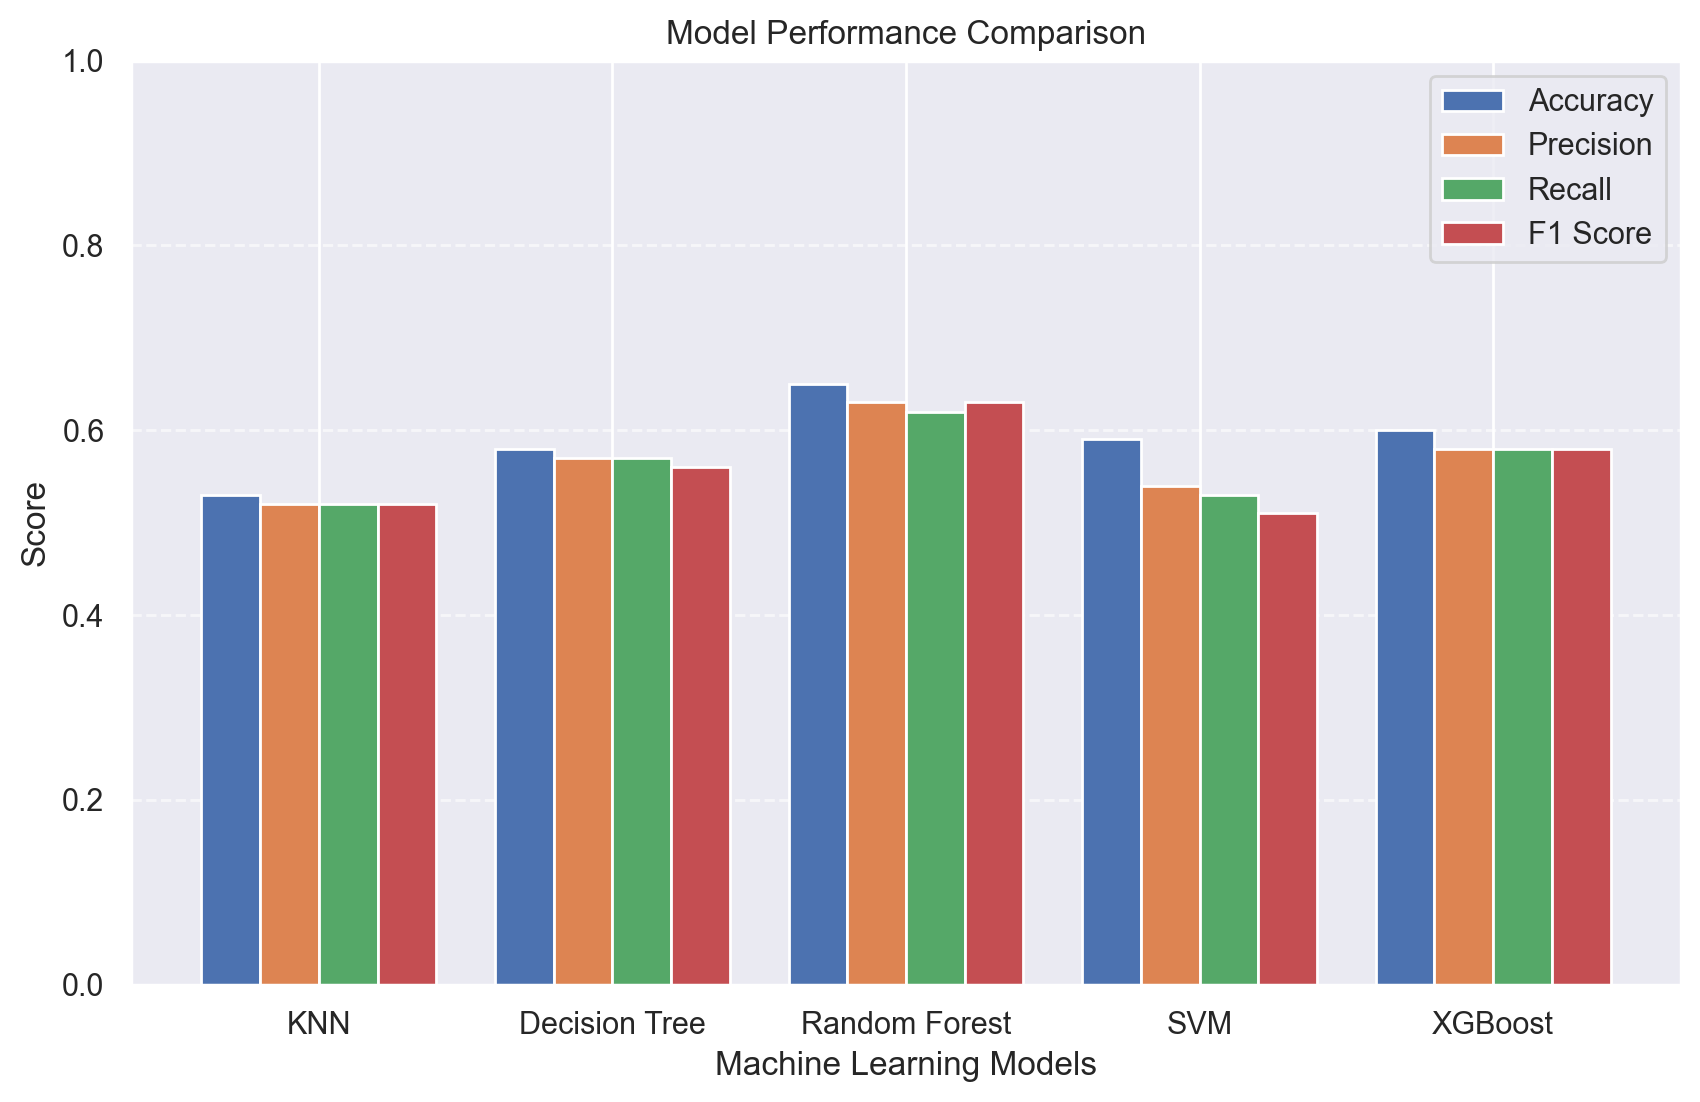

In [37]:

# Final Model Performance Results (Macro Avg Values)
results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Random Forest", "SVM", "XGBoost"],

    "Accuracy":  [0.53, 0.58, 0.65, 0.59, 0.60],
    "Precision": [0.52, 0.57, 0.63, 0.54, 0.58],
    "Recall":    [0.52, 0.57, 0.62, 0.53, 0.58],
    "F1 Score":  [0.52, 0.56, 0.63, 0.51, 0.58]
})


models = results["Model"]

accuracy  = results["Accuracy"]
precision = results["Precision"]
recall    = results["Recall"]
f1_score  = results["F1 Score"]

x = np.arange(len(models))   # positions
width = 0.2                  # bar width

plt.figure(figsize=(10,6))

# Bars for each metric
plt.bar(x - 1.5*width, accuracy,  width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall,    width, label="Recall")
plt.bar(x + 1.5*width, f1_score,  width, label="F1 Score")

# Labels and title
plt.xticks(x, models)
plt.ylim(0, 1)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Machine Learning Models")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
By comparison of various model now we know that Random forest has achieved overall highest performance among all models with better accuracy, precision, recall, and F1 score, making it the most suitable model for this classification task.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 6.7 |</span><span style='color:white'> Cross-Validation</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
Model Evaluation on Accuracy, Precision, Recall and F1 Score for all the model is carried out here.

In [38]:
models = {
    "SVC": SVC(probability=True),
    
    "Random Forest": RandomForestClassifier(random_state=42),
    
    "KNN":KNeighborsClassifier(),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "XGBoost":XGBClassifier(eval_metric="logloss",random_state=42)
}

In [39]:
#Stratified CV ensures balance in each class
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross Validation Scores:\n")

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_resampled, 
        y_train_resampled, 
        cv=cv,
        scoring="accuracy")
    print(f"{name} Mean Accuracy: {scores.mean():.4f}")

Cross Validation Scores:

SVC Mean Accuracy: 0.5097
Random Forest Mean Accuracy: 0.7087
KNN Mean Accuracy: 0.5832
Decision Tree Mean Accuracy: 0.6161
XGBoost Mean Accuracy: 0.6793


In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross Validation Scores:\n")

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train_resampled,
        y_train_resampled, 
        cv=cv,
        scoring="precision")
    print(f"{name} Mean Precision: {scores.mean():.4f}")

Cross Validation Scores:

SVC Mean Precision: 0.5343
Random Forest Mean Precision: 0.7100
KNN Mean Precision: 0.5763
Decision Tree Mean Precision: 0.6119
XGBoost Mean Precision: 0.6698


In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross Validation Scores:\n")

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train_resampled,
        y_train_resampled, 
        cv=cv,
        scoring="recall")
    print(f"{name} Mean Recall: {scores.mean():.4f}")

Cross Validation Scores:

SVC Mean Recall: 0.1790
Random Forest Mean Recall: 0.7059
KNN Mean Recall: 0.6308
Decision Tree Mean Recall: 0.6364
XGBoost Mean Recall: 0.7084


In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross Validation Scores:\n")

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train_resampled,
        y_train_resampled, 
        cv=cv,
        scoring="f1")
    print(f"{name} Mean F1: {scores.mean():.4f}")

Cross Validation Scores:

SVC Mean F1: 0.2661
Random Forest Mean F1: 0.7078
KNN Mean F1: 0.6019
Decision Tree Mean F1: 0.6237
XGBoost Mean F1: 0.6882


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inferences:</font></h2>

On the Cross-validation of all machine learning  models (RF,SVC,DT,KNN & XGB) which were evaluated by Accuracy, Precision,Recall & F1 score shows the results that Random Forest and XGBoost have achieved higher values on all evaluation metrics.These two are most reliable models that helps in distinguishing water to potable and non-potable.
Based on all these findings Random Forest and XGBoost can be taken as the suitable model in predicting Water potability. 

<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Hyper Parameter Tuning </p>

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 7 |</span><span style='color:white'> Hyperparameter Tuning</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

After cross-validation it is confirmed that both Random Forest or XGBoost show the highest accuracy, precision, recall and F1-scores. Hence we are applying hyperparameter tuning to improve their performance.
<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inferences:</font></h2>

* Since the water potability dataset is imbalanced, accuracy alone may be misleading.So, here we use F1-score as primary metric during hyperparameter tuning because it provides a balance between precision and recall. 

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 7.1 |</span><span style='color:white'>Random Forest Hyperparameter Tuning  </span></b>

 <div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
 For performing Hyperparameter Tuning we have selected GridSearchCV mainly because the parameter grid was small and we wanted the best possible combination, also gives most accurate results.

In [43]:
rf =RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

#GridSearch CV
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


rf_grid.fit(X_train_resampled, y_train_resampled)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest Scores:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best Random Forest Scores: 0.6999637026660239


 <div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

- GridSearchCV was used to optimize the Random Forest Classifier. 
- The best model here obtained 300 estimators, a minimum leaf of size 2 and no restriction on tree depth.
- The model achieved cross-validation f1-score of 0.70, which means its performs well in predicting both potable and non-potable water samples in a balanced way.

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 7.2 |</span><span style='color:white'> XGBoost Hyperparameter Tuning </span></b>

In [44]:
xgb = XGBClassifier(eval_metric="logloss",random_state=42)

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

xgb_grid.fit(X_train_resampled, y_train_resampled)

print(" Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best XGBoost Scores:", xgb_grid.best_score_)

 Best XGBoost Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost Scores: 0.6974699465800871


 <div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">

* GridSearchCV was used to to try different XGBoost settings using 5-fold cross-validation.It chose the best model based on the highest F1-Score, and it used all CPU cores (n=jobs=-1) to run faster.

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Conclusion:</font></h2>
As we move to the conclusion we can now select the best model by GridSearchCV results, the Random Forest model appears to have scored highest cross-validated F1-score compared to the XGBoost. As we said earlier why we choose F1-Score because it provides a balanced measure of Precision,Recall and Accuracy.So as per the result Random Forest is selected as the best model.

In [45]:
# Selecting Random Forest as the final model
final_model = rf_grid.best_estimator_
y_pred = final_model.predict(X_test)

<a id="import"></a>
# <p style="background-color:white; font-family:calibri; color:skyblue; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 | Model Evaluation </p>

<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 8.1 |</span><span style='color:white'>Model Evaluation using accuracy, precision, recall, F1-score and Confusion Matrices </span></b>

Accuracy: 0.6524390243902439
Precision: 0.5608695652173913
Recall: 0.50390625
F1 Score: 0.5308641975308642

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.75      0.72       400
           1       0.56      0.50      0.53       256

    accuracy                           0.65       656
   macro avg       0.63      0.63      0.63       656
weighted avg       0.65      0.65      0.65       656


Confusion Matrix:
 [[299 101]
 [127 129]]


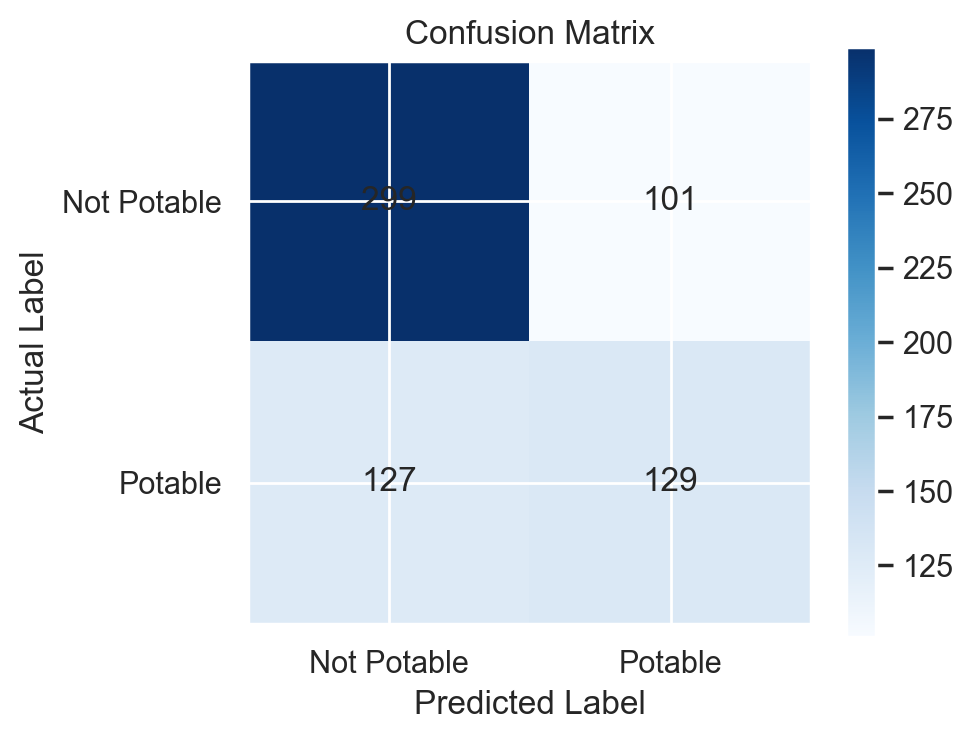

In [52]:

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Not Potable", "Potable"])
plt.yticks([0, 1], ["Not Potable", "Potable"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inference:</font></h2>

* The model achieved an accuracy of **65.2%** , indicating moderative predictive performance.
* The precision value of **0.56** shows that more than half of the samples predicted as potable were correct.
* The recall score **0.50** reminds that the model was able to identify about half of the actual potable water sample.




As per the Confusion matrices visualization

*  True Negatives(299) - shows us that the model actually predicted **299 as non-potable( unsafe water)**
* False Positives(101) -  Here the model predicted **101 samples as non-potable which were actually potable (can be termed as safe water)**
* False Negatives(127) - The model predicted **127 potable (safe) samples as non-potable**, meaning some safe water samples were wrongly classified as unsafe.
* True Positives(129)- The model correctly identified **129 of the water sample as potable(Safe water)**.

What the Heatmap Shows:
* The brightest cell **(299) shows that the model performs best at detecting non-potable water**.
* The values **(101 & 127) that comes diagonally , shows that the model can make misclassification**.


<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 8.2 |</span><span style='color:white'>ROC Curve & AUC Score </span></b>


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inferences:</font></h2>
 [:,1] here the probability taken is class(potable water)
 fpr - False Positive Rate
 tpr - True Positive Rate

 Random Forest ROC-AUC Score: 0.664326171875


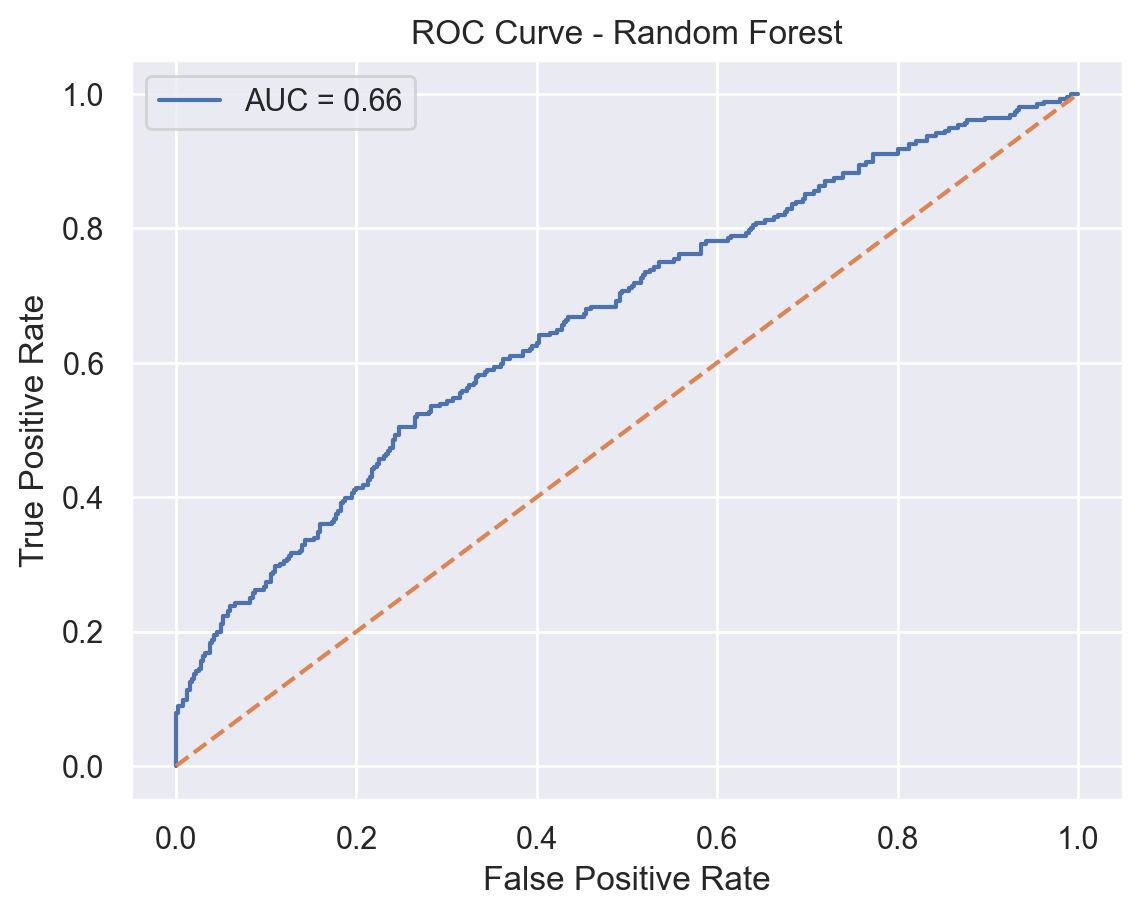

In [49]:


# Probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# ROC Curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score  = roc_auc_score(y_test, y_prob)

print(" Random Forest ROC-AUC Score:", auc_score)

# Plot ROC Curve
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


In [53]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, auc_score]
})

print(results)

      Metric     Score
0   Accuracy  0.652439
1  Precision  0.560870
2     Recall  0.503906
3   F1 Score  0.530864
4    ROC-AUC  0.664326


<a id="basic"></a>
# <b><span style='color:#0699ee'>Step 9 |</span><span style='color:white'>Feature Importance </span></b>


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Inferences:</font></h2>
The feature importance plot is used here to understand the most influential water quality parameter used by the Random Forest model.
Features with higher importance scores contribute more in predicting whether the water is potable or not.

Feature Importance Ranking:

           Feature  Importance
0               ph    0.137164
4         Sulphate    0.122806
2           Solids    0.122095
3      Chloramines    0.115429
1         Hardness    0.115026
5     Conductivity    0.098871
8        Turbidity    0.097668
6   Organic_carbon    0.096698
7  Trihalomethanes    0.094242


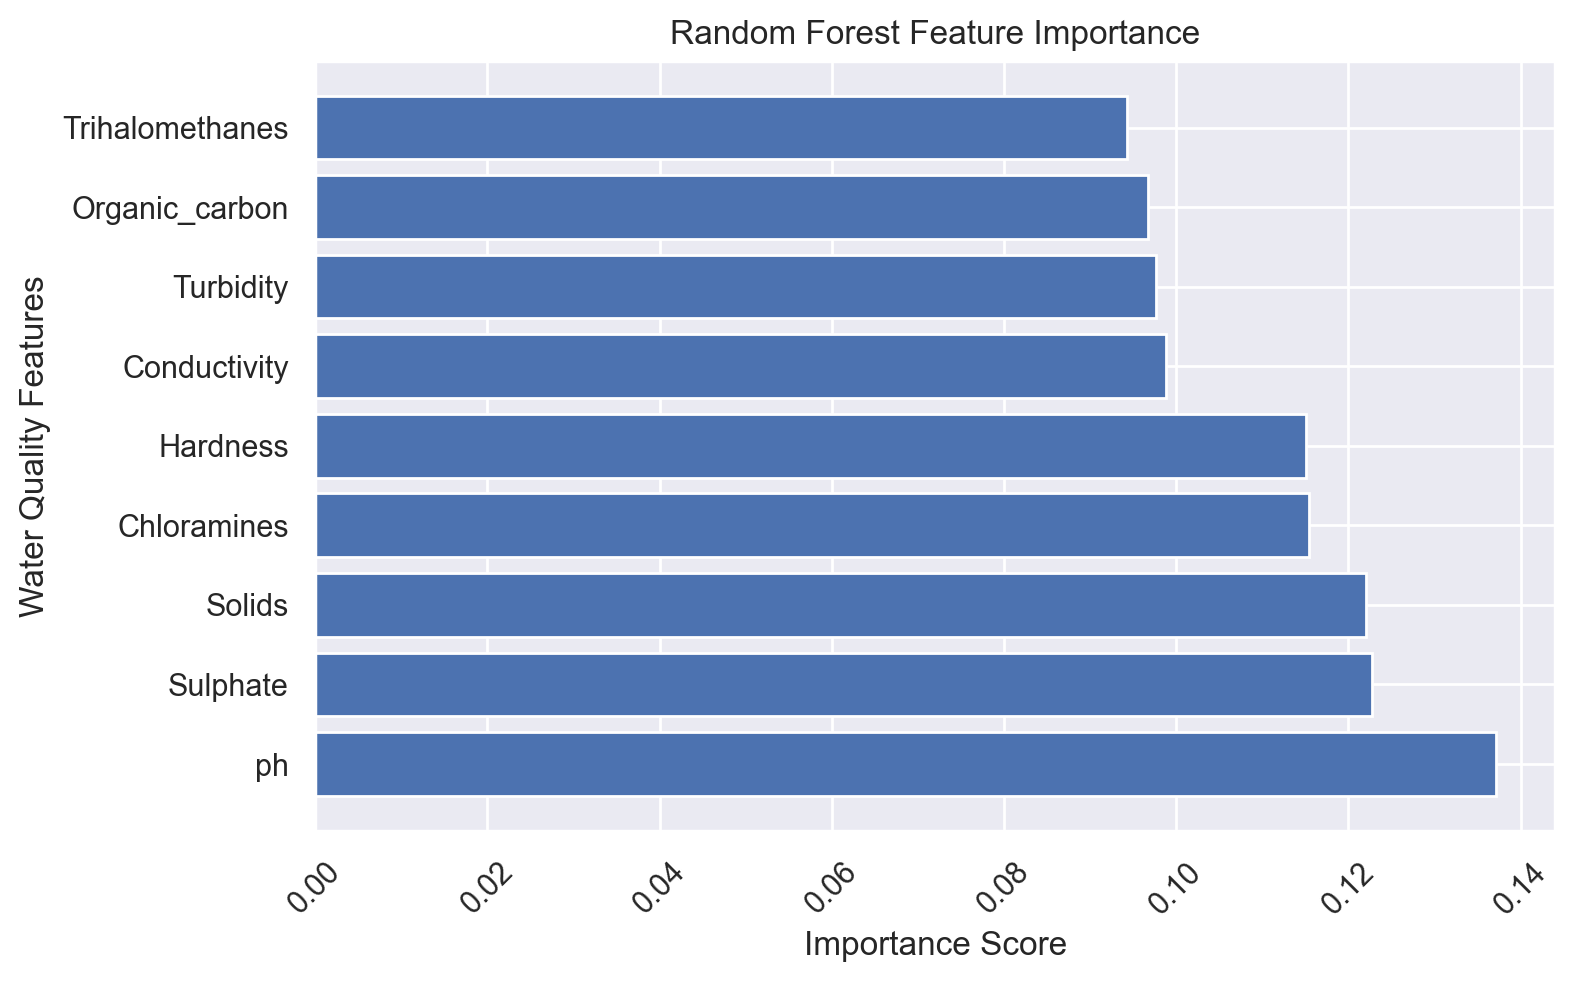

In [54]:
# For getting feature importance values from random Forest
importances = final_model.feature_importances_

#Creating a Dataframe with feature names
feature_importance_df = final_model.feature_importances_


feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances 
})

#sorting features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance Ranking:\n")
print(feature_importance_df)

#Visualization of Feature importance
plt.figure(figsize=(8,5))
plt.barh( feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Water Quality Features")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Conclusion:</font></h2>
The feature important analysis how one parameter can influence the model in predicting water potability. So for example take the importance value of pH, which is having a importance of 0.13, which means its variation can significantly affect the model's decision. At the same time feature importance doesn't guarantee whether higher or lower ph directly makes the water potable or non-potable.

In [55]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, auc_score]
})

print(results)

      Metric     Score
0   Accuracy  0.652439
1  Precision  0.560870
2     Recall  0.503906
3   F1 Score  0.530864
4    ROC-AUC  0.664326


<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left">
<h2 align="left"><font color=black>Model Evaluation Result </font></h2>

The final tuned Random Forest Model was evaluated on the test dataset using multiple metrics.
The results are summarized below:
| Metric     | Score |
|------------|-------|
| Accuracy   | 0.65  |
| Precision  | 0.56  |
| Recall     | 0.50  |
| F1 Score   | 0.53  |
| ROC-AUC    | 0.66  |

These results indicates that the model provides moderate performance in predicting water potability, with better classification ability than random guessing.

<div style="border-radius:10px; padding: 15px; background-color: #0699ee; font-size:115%; text-align:left"> 
Saving the model using joblib

In [56]:
import joblib
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [57]:
# saving the trained model
joblib.dump(final_model,"Water_Potability_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model saved successfully")

Model saved successfully
